In [46]:
import kagglehub
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from utils_preprocess import preprocess_dataset
from feature_selection import anova_feature_selection, intra_class_deviation, combined_ranking, plot_feature_importance
from collections import Counter
from SMOTE import make_classification, plot_class_distribution, aplicar_smote
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, KFold, LeaveOneOut, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.datasets import load_iris
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import datetime as dt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from confusion_matrix_multiclass import (
    calculate_confusion_matrix,
    plot_confusion_matrix,
    calculate_metrics,
    plot_multiclass_roc_curve
)


In [51]:
df = pd.read_csv('C:\\Users\\windows\\.cache\\kagglehub\\datasets\\amar5693\\retail-business-analytics-dataset-10k-orders\\versions\\1\\Business_Analytics_Dataset_10000_Rows.csv')
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["year"] = df["Order_Date"].dt.year
df["month"] = df["Order_Date"].dt.month
df["day"] = df["Order_Date"].dt.day
df["weekday"] = df["Order_Date"].dt.weekday  # 0=Lunes, 6=Domingo
df.head()

,Order_ID,Customer_ID,Order_Date,Region,Product_Category,Customer_Segment,Quantity,Unit_Price,Discount_Rate,Revenue,Cost,Profit,Payment_Method,year,month,day,weekday
0,1,CUST3818,2024-08-18,North,Clothing,Corporate,5,300.68,0.27,1097.48,768.29,329.19,Credit Card,2024,8,18,6
1,2,CUST9689,2024-06-19,South,Beauty,Home Office,9,32.89,0.02,290.09,179.33,110.76,Debit Card,2024,6,19,2
2,3,CUST9147,2024-11-21,West,Sports,Corporate,5,345.61,0.25,1296.04,1022.60,273.44,Credit Card,2024,11,21,3
3,4,CUST7938,2024-07-19,North,Clothing,Consumer,1,444.50,0.06,417.83,280.99,136.84,UPI,2024,7,19,4
4,5,CUST5127,2024-10-28,South,Home & Kitchen,Consumer,5,65.13,0.21,257.26,151.90,105.36,Credit Card,2024,10,28,0


In [52]:
print("Dataset original:")
print(df)
print("\n" + "="*50 + "\n")

# Aplicamos el preprocesamiento
procesado = preprocess_dataset(df, target_col='Profit')

print("\nDataset preprocesado:")
print(procesado)

Dataset original:
      Order_ID Customer_ID Order_Date Region Product_Category  \
0            1    CUST3818 2024-08-18  North         Clothing   
1            2    CUST9689 2024-06-19  South           Beauty   
2            3    CUST9147 2024-11-21   West           Sports   
3            4    CUST7938 2024-07-19  North         Clothing   
4            5    CUST5127 2024-10-28  South   Home & Kitchen   
...        ...         ...        ...    ...              ...   
9995      9996    CUST9137 2024-06-30   West           Beauty   
9996      9997    CUST3663 2024-08-21   East         Clothing   
9997      9998    CUST2546 2024-04-05  South         Clothing   
9998      9999    CUST9750 2024-05-13   East           Sports   
9999     10000    CUST8377 2024-06-12  North      Electronics   

     Customer_Segment  Quantity  Unit_Price  Discount_Rate  Revenue     Cost  \
0           Corporate         5      300.68           0.27  1097.48   768.29   
1         Home Office         9       32.

El DF se tiene a nivel orden, ahora agrupemos a nivel cliente para obtener los niveles de cliente con un clasificador.

In [53]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Order_Date', 'Region', 'Product_Category',
       'Customer_Segment', 'Quantity', 'Unit_Price', 'Discount_Rate',
       'Revenue', 'Cost', 'Profit', 'Payment_Method', 'year', 'month', 'day',
       'weekday'],
      dtype='str')

In [58]:
df_cliente = procesado.groupby(['Customer_ID', 'Region', 'Product_Category',
       'Customer_Segment', 'Unit_Price', 'Discount_Rate', 'Payment_Method', 'year', 'month', 'day',
       'weekday']).agg({"Profit": "sum",
                                            "Quantity": "sum", 
                                            "Revenue": "sum",
                                            "Cost": "sum"}).reset_index()
df_cliente2 = df_cliente.copy()

#Segmentamos por cuartiles usando el target variable "Profit"
df_cliente2 ["segmentacion"] = pd.qcut(df_cliente2["Profit"], q=10, labels=['q1','q2','q3','q4','q5','q6','q7','q8','q9','q10'])

### Usando todos los modelos vistos en clase y casi todas las métricas igual para el target de "segmentacion" que clasifica clientes respecto a su profit.


MODELO: KNN (k=1)


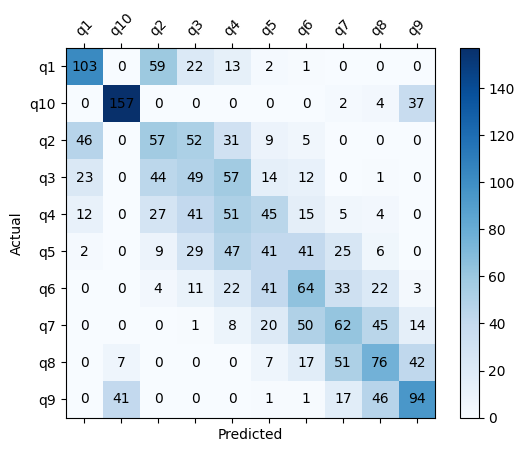

                 accuracy: 0.377000
        balanced_accuracy: 0.377000
          precision_macro: 0.379004
             recall_macro: 0.377000
                 f1_macro: 0.377700
       precision_weighted: 0.379004
          recall_weighted: 0.377000
              f1_weighted: 0.377700
                      mcc: 0.203174

MODELO: KNN (k=3)


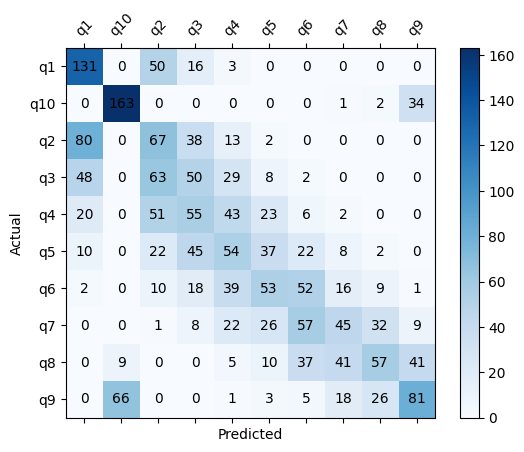

                 accuracy: 0.363000
        balanced_accuracy: 0.363000
          precision_macro: 0.360443
             recall_macro: 0.363000
                 f1_macro: 0.354899
       precision_weighted: 0.360443
          recall_weighted: 0.363000
              f1_weighted: 0.354899
                      mcc: 0.211704

MODELO: KNN (k=5)


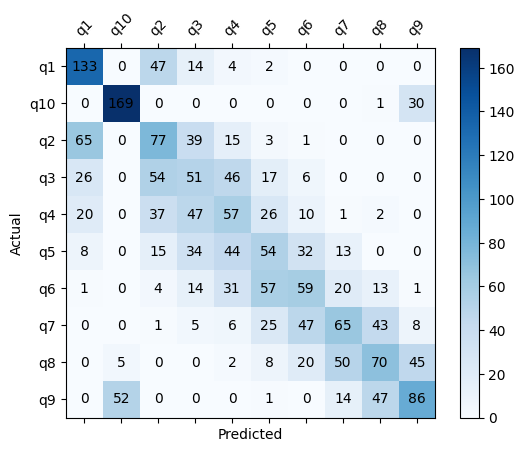

                 accuracy: 0.410500
        balanced_accuracy: 0.410500
          precision_macro: 0.404851
             recall_macro: 0.410500
                 f1_macro: 0.405341
       precision_weighted: 0.404851
          recall_weighted: 0.410500
              f1_weighted: 0.405341
                      mcc: 0.233214

MODELO: Regresión Logística


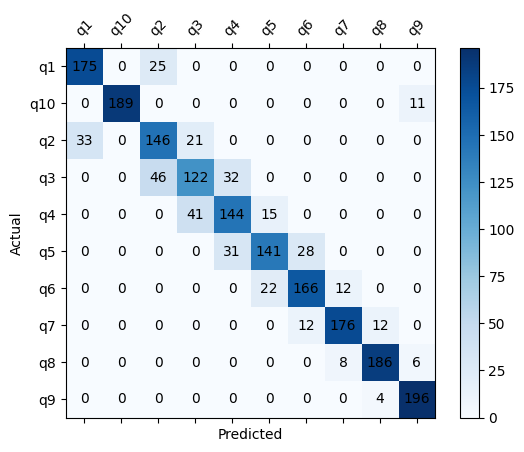

                 accuracy: 0.820500
        balanced_accuracy: 0.820500
          precision_macro: 0.820975
             recall_macro: 0.820500
                 f1_macro: 0.820002
       precision_weighted: 0.820975
          recall_weighted: 0.820500
              f1_weighted: 0.820002
                      mcc: 0.678483

MODELO: J48 (Entropy Tree)


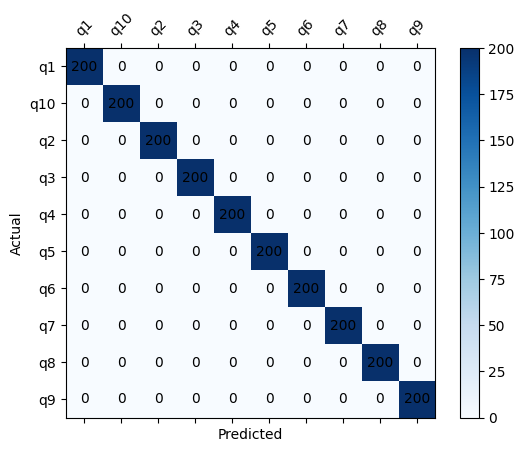

                 accuracy: 1.000000
        balanced_accuracy: 1.000000
          precision_macro: 1.000000
             recall_macro: 1.000000
                 f1_macro: 1.000000
       precision_weighted: 1.000000
          recall_weighted: 1.000000
              f1_weighted: 1.000000
                      mcc: 1.000000

MODELO: Random Forest


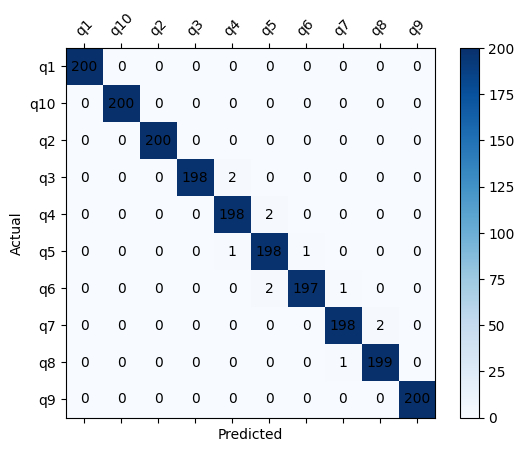

                 accuracy: 0.994000
        balanced_accuracy: 0.994000
          precision_macro: 0.994027
             recall_macro: 0.994000
                 f1_macro: 0.994005
       precision_weighted: 0.994027
          recall_weighted: 0.994000
              f1_weighted: 0.994005
                      mcc: 0.986775

MODELO: SVM (RBF)


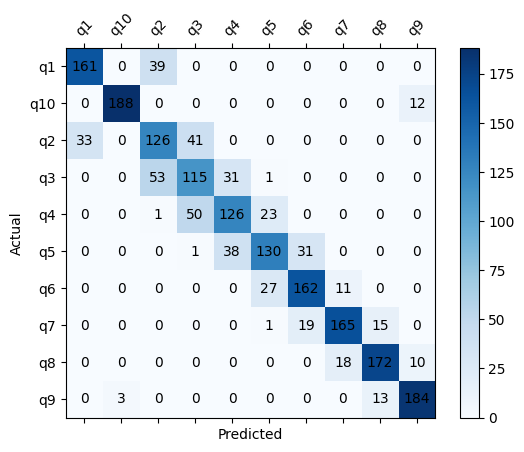

                 accuracy: 0.764500
        balanced_accuracy: 0.764500
          precision_macro: 0.767340
             recall_macro: 0.764500
                 f1_macro: 0.765442
       precision_weighted: 0.767340
          recall_weighted: 0.764500
              f1_weighted: 0.765442
                      mcc: 0.598227

MODELO: MLP


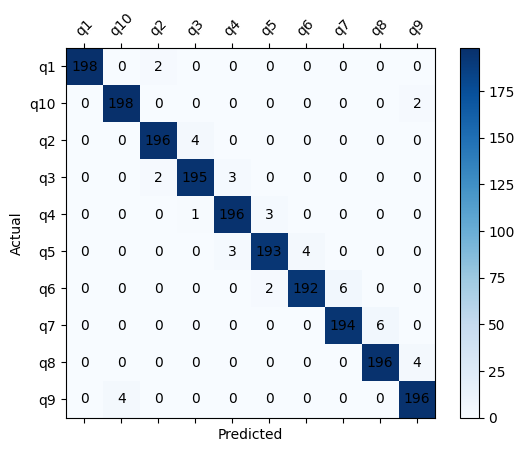

                 accuracy: 0.977000
        balanced_accuracy: 0.977000
          precision_macro: 0.977043
             recall_macro: 0.977000
                 f1_macro: 0.976997
       precision_weighted: 0.977043
          recall_weighted: 0.977000
              f1_weighted: 0.976997
                      mcc: 0.950019

MODELO: Naive Bayes


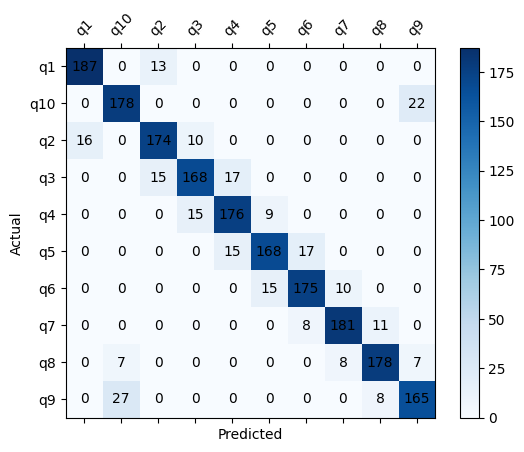

                 accuracy: 0.875000
        balanced_accuracy: 0.875000
          precision_macro: 0.875243
             recall_macro: 0.875000
                 f1_macro: 0.874920
       precision_weighted: 0.875243
          recall_weighted: 0.875000
              f1_weighted: 0.874920
                      mcc: 0.750844

################################################################################
TABLA COMPARATIVA FINAL
################################################################################


<Figure size 1000x600 with 0 Axes>

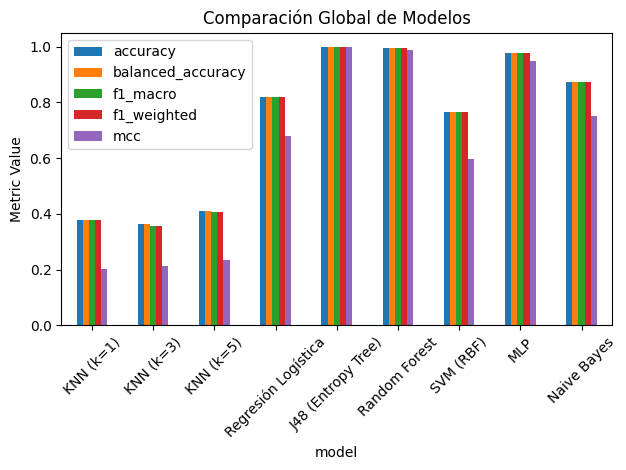

In [59]:
SEMILLA = 42
X = df_cliente2.drop(columns=['segmentacion'])
y = df_cliente2['segmentacion']
class_names = ['segmentacion']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEMILLA, stratify=y)


# 2. Definir modelos a evaluar con scikit-learn
models = {
    "KNN (k=1)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=1))
    ]),
    "KNN (k=3)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=3))
    ]),
    "KNN (k=5)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ]),
    "Regresión Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000))
    ]),
    "J48 (Entropy Tree)": DecisionTreeClassifier(
        criterion="entropy",
        random_state=SEMILLA
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=SEMILLA
    ),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, random_state=SEMILLA))
    ]),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(32,16),
            max_iter=3000,
            random_state=SEMILLA
        ))
    ]),
    "Naive Bayes": GaussianNB()
}

#Evaluación sin LOO, solo con train/test split
all_results = []

for name, model in models.items():

    print("\n" + "="*80)
    print(f"MODELO: {name}")
    print("="*80)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    cm, classes = calculate_confusion_matrix(y_test, y_pred)
    plot_confusion_matrix(cm, classes)

    metrics = calculate_metrics(cm, classes)

    for k, v in metrics.items():
        print(f"{k:>25}: {v:.6f}")

    '''roc_macro, roc_micro, roc_per_class = plot_multiclass_roc_curve(
        y_true=y_test,
        y_scores=y_scores,
        classes=classes,
        title=f"ROC Curve - {name}"
    )

    metrics["roc_auc_macro"] = roc_macro
    metrics["roc_auc_micro"] = roc_micro'''
    metrics["model"] = name

    all_results.append(metrics)

# 4. Tabla comparativa
df_results = pd.DataFrame(all_results)
df_results = df_results.set_index("model")

print("\n" + "#"*80)
print("TABLA COMPARATIVA FINAL")
print("#"*80)
#print(df_results.sort_values(by="roc_auc_macro", ascending=False))

# 5. Graficar resultados
metrics_to_plot = [
    "accuracy",
    "balanced_accuracy",
    "f1_macro",
    "f1_weighted",
    "mcc",
#    "roc_auc_macro"
]

plt.figure(figsize=(10,6))
'''df_results[metrics_to_plot].sort_values(
    by="roc_auc_macro",
    ascending=False
).plot(kind="bar")'''
df_results[metrics_to_plot].plot(kind="bar")
plt.title("Comparación Global de Modelos")
plt.ylabel("Metric Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()